In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path='Visadataset.csv'
visa_df=pd.read_csv(path)
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [2]:
# we have two columns
# can  & num
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [3]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [4]:
# how many assia students got certified
# how many aisa student got denied

# idea
# con1=visa_df['continent']=='Asia'
# con2=shortlist certified
# con= con1 & con2
# extract the data

In [5]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
con=con1 & con2
len(visa_df[con])

11012

In [6]:
continent_labels=visa_df['continent'].unique()
certified_list=[]
for i in continent_labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con=con1 & con2
    certified_list.append(len(visa_df[con]))
certified_list

[11012, 397, 2037, 2957, 493, 122]

In [7]:
continent_labels=visa_df['continent'].unique()
certified_list=[]
denied_list=[]
for i in continent_labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    certi_con=con1 & con2
    deni_con=con1 & con3
    certified_list.append(len(visa_df[certi_con]))
    denied_list.append(len(visa_df[deni_con]))
certified_list,denied_list
pd.DataFrame(zip(certified_list,denied_list),
            index=continent_labels,
            columns=['Certified','Denied'])

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [8]:
con=visa_df['case_status']=='Certified'
visa_df[con].groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [9]:
col1=visa_df['continent']
col2=visa_df['case_status']
r1=pd.crosstab(col1,col2)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [10]:
col1=visa_df['continent']
col2=visa_df['case_status']
r2=pd.crosstab(col2,col1)
r2

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


<Axes: xlabel='continent'>

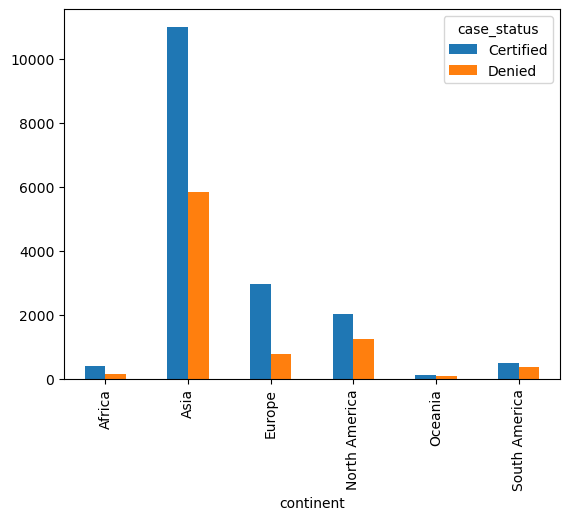

In [11]:
r1.plot(kind='bar')

<Axes: xlabel='case_status'>

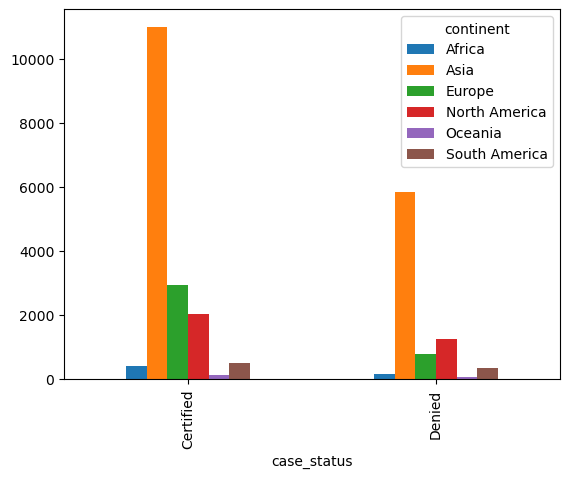

In [12]:
r2.plot(kind='bar')

In [13]:
# continent
# education of employee
# case_status
# there are 11k applicants certified from Asia
# Now i want to know these 11k based on education

In [14]:
# select col1
# select con2
# select con3
# cols=[col2,col3]
# pd.crosstab(index,columns)
# pd.crosstab(col1,col2)

In [15]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col3]
pd.crosstab(col1,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                       143        54          66      288          0   
Asia                           0         0           0        0       7168   
Europe                         0         0           0        0          0   
North America                  0         0           0        0          0   
Oceania                        0         0           0        0          0   
South America                  0         0           0        0          0   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
continent                                                                   
Africa                        0           0        0          0         0   
Asia                        923        2290     6480          0         0   
Europe                        0           0        0       1299       846   
North America                 0           0        0          0         0   
Oceania                       0           0        0          0         0   
South America                 0           0        0          0         0   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
continent              ...                                               
Africa                 ...             0        0          0         0   
Asia                   ...             0        0          0         0   
Europe                 ...             0        0          0         0   
North America          ...           401     1408          0         0   
Oceania                ...             0        0         66        22   
South America          ...             0        0          0         0   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
continent                                                            
Africa                          0        0             0         0   
Asia                            0        0             0         0   
Europe                          0        0             0         0   
North America                   0        0             0         0   
Oceania                        36       68             0         0   
South America                   0        0           333        89   

continent                                   
education_of_employee High School Master's  
continent                                   
Africa                          0        0  
Asia                            0        0  
Europe                          0        0  
North America                   0        0  
Oceania                         0        0  
South America                 137      293  

[6 rows x 24 columns]

In [16]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col3,col2]
pd.crosstab(col1,cols)

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
continent                                                                     
Africa                        81     62        43     11          23     43   
Asia                        4407   2761       780    143         676   1614   
Europe                      1040    259       788     58         162    328   
North America                641    584       207     51         210    191   
Oceania                       38     28        19      3          19     17   
South America                160    173        75     14          74     63   

education_of_employee  Master's         
case_status           Certified Denied  
continent                               
Africa                      250     38  
Asia                       5149   1331  
Europe                      967    130  
North America               979    429  
Oceania                      46     22  
South America               184    109

## Numerical-Numerical

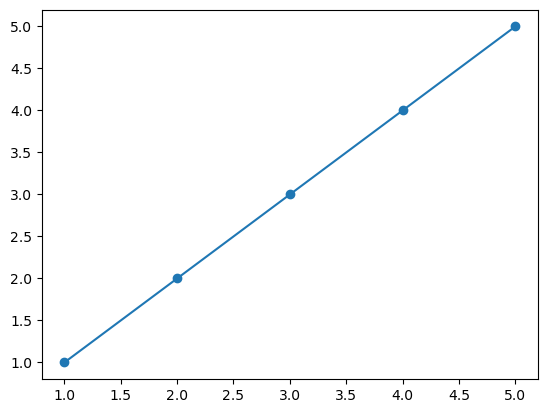

In [19]:
x=[1,2,3,4,5]
y=[1,2,3,4,5]
plt.scatter(x,y)
plt.plot(x,y)

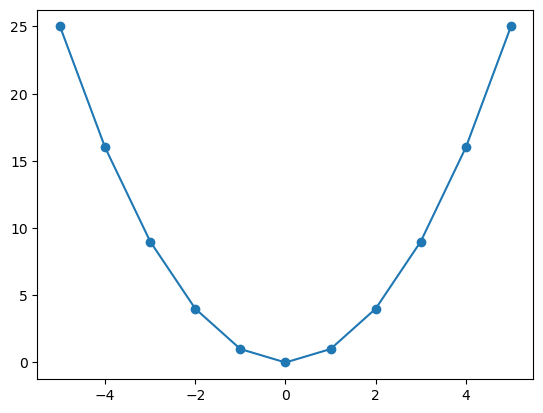

In [27]:
# x=[i for i in range(1,10)]
x=list(range(-5,6))
y=[i**2 for i in x]
plt.scatter(x,y)
plt.plot(x,y)

In [28]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

Text(0, 0.5, 'prevailing_wage')

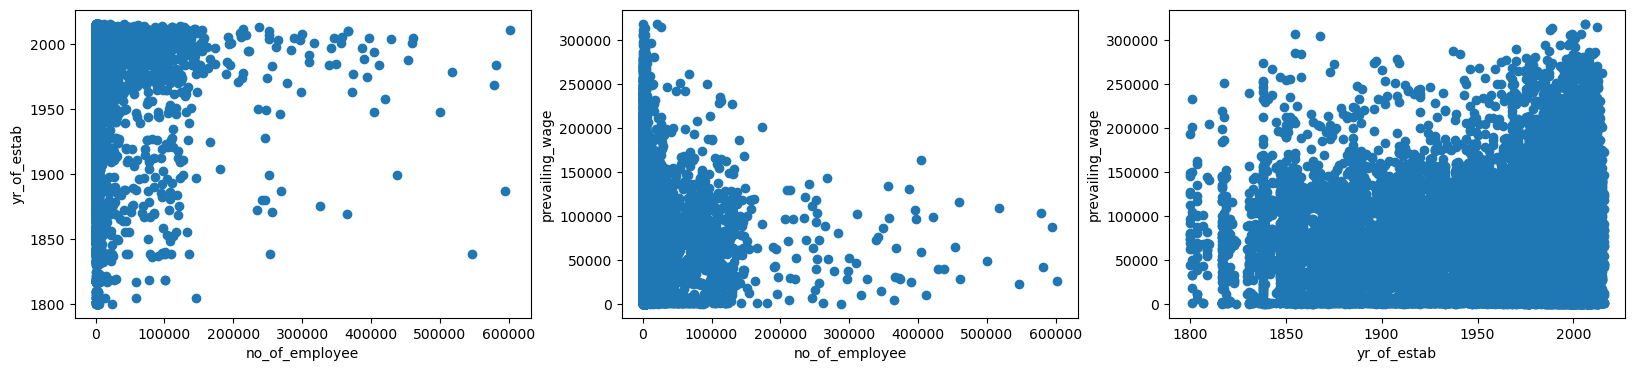

In [33]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(20,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.xlabel('no_of_employee')
plt.ylabel('yr_of_estab')
#==============================
plt.subplot(1,3,2).scatter(col1,col3)
plt.xlabel('no_of_employee')
plt.ylabel('prevailing_wage')
#==============================
plt.subplot(1,3,3).scatter(col2,col3)
plt.xlabel('yr_of_estab')
plt.ylabel('prevailing_wage')

## Correlation

In [34]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


## Heat map

<Axes: >

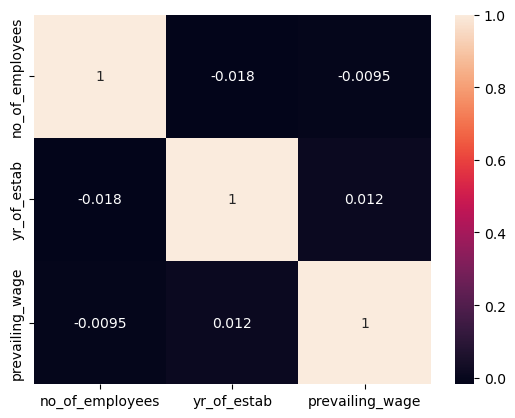

In [36]:
import seaborn as sns
corr=visa_df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [41]:
path='winequality_red.csv'
red_df=pd.read_csv(path)
cat=red_df.select_dtypes(include='object').columns
num=red_df.select_dtypes(exclude='object').columns

In [42]:
cat

Index([], dtype='object')

In [43]:
num

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

<Axes: >

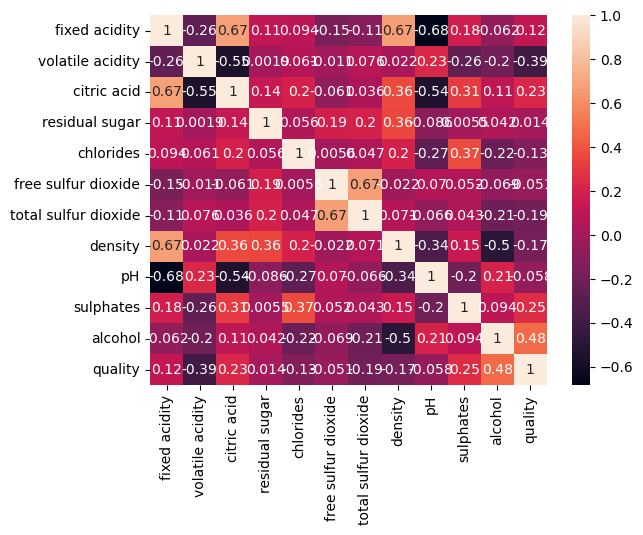

In [44]:
corr=red_df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

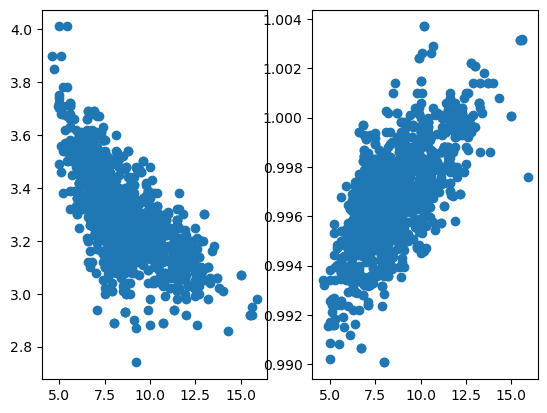

In [46]:
col1=red_df["fixed acidity"]
col2=red_df["pH"]
col3=red_df["density"]
plt.subplot(1,2,1).scatter(col1,col2)
plt.subplot(1,2,2).scatter(col1,col3)

